In [345]:
# bibliotecas
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [346]:
df_labels = pd.read_excel('Data_labels.xlsx')
df_store = pd.read_excel('Data_store.xlsx')

print(df_labels.head())
print(df_store.head())

   idstore  sku     brand oldpvp new_pvp (discount)  labelqty weight (g)  \
0        1    1  Marca  1   4.22        2.11 (0.50)         1        260   
1        1    1   Marca 1   3.96        1.98 (0.50)         1        260   
2        1    1  Marca  1   4.74        2.37 (0.50)         1        260   
3        1    1   Marca 1    4.2         2.1 (0.50)         1        260   
4        1    1  Marca  1   4.62        2.31 (0.50)         1        260   

  Payment_method  Margin (%)  Profit (€)  perc_expiring_sku expiring_date  \
0           Card          16      0.3376           0.010050    03/10/2021   
1                         16      0.3168           0.005025    02/10/2021   
2           Cash          16      0.3792           0.010050    03/10/2021   
3           Card          16      0.3360           0.010050    03/10/2021   
4           Cash          16      0.3696           0.010050    03/10/2021   

  labelling_date  sell_date  sold  
0     2021-10-01 2021-10-02   1.0  
1     20

### Exploração Inicial

In [347]:
dfinfo_labels = pd.DataFrame({
    'dtype': df_labels.dtypes,
    'non_null': df_labels.notna().sum(),
    'nulls': df_labels.isna().sum()
}).sort_values('dtype')
dfinfo_labels

,dtype,non_null,nulls
idstore,int64,150054,0
sku,int64,150054,0
labelqty,int64,150054,0
Margin (%),int64,150054,0
Profit (€),float64,150054,0
perc_expiring_sku,float64,149929,125
labelling_date,datetime64[ns],150054,0
sell_date,datetime64[ns],80511,69543
sold,float64,149940,114
brand,object,150054,0


<small>

#### df_labels — antes

| Coluna             | Tipo        | Nulos  | Exemplo      |
|--------------------|-------------|--------|--------------|
| idstore            | int64       | 0      | 1            |
| sku                | int64       | 0      | 1            |
| brand              | object      | 0      | Marca  1     |
| oldpvp             | object      | 22     | 4.22         |
| new_pvp (discount) | object      | 28     | 2.11 (0.50)  |
| labelqty           | int64       | 0      | 1            |
| weight (g)         | object      | 4      | 260          |
| Payment_method     | object      | 0      | Card         |
| Margin (%)         | int64       | 0      | 16           |
| Profit (€)         | float64     | 0      | 0.3376       |
| perc_expiring_sku  | float64     | 125    | 0.01         |
| expiring_date      | object      | 0      | 03/10/2021   |
| labelling_date     | datetime64  | 0      | 2021-10-01   |
| sell_date          | datetime64  | 69543  | 2021-10-02   |
| sold               | float64     | 114    | 1.0          |

</small>

In [348]:
df_labels.describe(include='all').T.loc[df_labels.dtypes.sort_values().index]

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
idstore,150054.0,NaN,NaN,NaN,139.234242,1.0,59.0,135.0,212.0,332.0,87.056044
sku,150054.0,NaN,NaN,NaN,163.699422,1.0,99.0,160.0,236.0,319.0,87.247006
labelqty,150054.0,NaN,NaN,NaN,1.0,1.0,1.0,1.0,1.0,1.0,0.0
Margin (%),150054.0,NaN,NaN,NaN,15.82495,10.0,13.0,17.0,19.0,20.0,3.303568
Profit (€),150054.0,NaN,NaN,NaN,0.175131,0.034,0.1245,0.1529,0.2224,99.9,0.268439
perc_expiring_sku,149929.0,NaN,NaN,NaN,0.385245,0.0,0.2,0.333333,0.666667,2.0,0.223626
labelling_date,150054,NaN,NaN,NaN,2021-10-16 16:41:47.577271808,2021-10-01 00:00:00,2021-10-10 00:00:00,2021-10-17 00:00:00,2021-10-25 00:00:00,2021-10-31 00:00:00,NaN
sell_date,80511,NaN,NaN,NaN,2021-10-17 18:22:01.846704384,2021-10-01 00:00:00,2021-10-11 00:00:00,2021-10-18 00:00:00,2021-10-25 00:00:00,2021-11-18 00:00:00,NaN
sold,149940.0,NaN,NaN,NaN,0.536568,0.0,0.0,1.0,1.0,1.0,0.498663
brand,150054,328,marca 2,18249,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [349]:
dfinfo_store = pd.DataFrame({
    'dtype': df_store.dtypes,
    'non_null': df_store.notna().sum(),
    'nulls': df_store.isna().sum()
}).sort_values('dtype')
dfinfo_store

,dtype,non_null,nulls
idstore,int64,342,0
selling_square_ft,float64,311,31
type,object,342,0
district,object,342,0


<small>

#### df_store — antes

| Coluna            | Tipo    | Nulos | Exemplo |
|-------------------|---------|-------|---------|
| idstore           | int64   | 0     | 1       |
| type              | object  | 0     | Large   |
| selling_square_ft | float64 | 31    | 4762.0  |
| district          | object  | 0     | Évora   |

</small>

In [350]:
df_store.describe(include='all').T.loc[df_store.dtypes.sort_values().index]

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
idstore,342.0,NaN,NaN,NaN,171.5,98.871128,1.0,86.25,171.5,256.75,342.0
selling_square_ft,311.0,NaN,NaN,NaN,5190.241158,4998.922534,10.0,1200.5,3673.0,7914.0,25258.0
type,342,4,Small,166,NaN,NaN,NaN,NaN,NaN,NaN,NaN
district,342,18,Lisboa,30,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [351]:
# duplicados
dupl_labels = df_labels.duplicated().sum()
dupl_store = df_store.duplicated().sum()
print(dupl_labels)
print(dupl_store)

33740
0


In [352]:
df_labels[df_labels.duplicated(keep=False)]
# validado que não são duplicados são repetição

,idstore,sku,brand,oldpvp,new_pvp (discount),labelqty,weight (g),Payment_method,Margin (%),Profit (€),perc_expiring_sku,expiring_date,labelling_date,sell_date,sold
33,7,2,Marca2,3.19,2.39 (0.25),1,222,,15,0.3585,0.111111,26/10/2021,2021-10-15,NaT,0.0
36,7,2,Marca2,3.19,2.39 (0.25),1,222,,15,0.3585,0.111111,26/10/2021,2021-10-15,NaT,0.0
37,7,2,Marca 2,3.19,2.39 (0.25),1,222,,15,0.3585,0.111111,26/10/2021,2021-10-15,NaT,0.0
39,7,2,Marca 2,3.19,2.39 (0.25),1,222,,15,0.3585,0.111111,26/10/2021,2021-10-15,NaT,0.0
40,7,2,Marca 2,3.19,2.39 (0.25),1,222,,15,0.3585,0.111111,26/10/2021,2021-10-15,NaT,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
150038,177,318,Marca 2,2.49,"1,24 (50%)",1,97,,11,0.1364,0.006289,19-10-2021,2021-10-18,NaT,0.0
150047,193,318,Marca 2,2.49,1.24 (0.50),1,97,Cash,11,0.1364,0.100629,19-10-2021,2021-10-03,2021-10-09,1.0
150048,193,318,Marca 2,2.49,1.24 (0.50),1,97,Cash,11,0.1364,0.100629,19-10-2021,2021-10-03,2021-10-09,1.0
150050,203,318,Marca2,2.49,1.24 (0.50),1,97,Cash,11,0.1364,0.113208,19-10-2021,2021-10-01,2021-10-02,1.0


### df_labels — Correção de Tipos e Normalização

In [353]:
# coluna brand
df_labels['brand'].unique()

array(['Marca  1', 'Marca 1', ' Marca 1', 'Marca   1', 'Marca1',
       'marca  2', 'marca 2', 'marca2', ' marca 2', 'marca   2',
       ' Marca 2', 'Marca2', 'Marca   2', 'Marca  2', 'Marca 2',
       'Marca 3', ' Marca 3', 'Marca   3', 'Marca  3', 'Marca3',
       'marca  3', 'marca   3', 'marca3', 'marca 3', ' marca 3', 'Marca4',
       ' Marca 4', 'Marca   4', 'Marca  4', ' marca 4', 'marca4',
       'Marca 4', 'marca  4', 'marca   4', 'marca 4', 'marca5',
       'marca   5', ' marca 5', 'marca  5', 'marca 5', 'Marca5',
       'Marca  5', 'Marca   5', ' Marca 5', 'Marca 5', 'Marca6',
       'Marca 6', 'Marca  6', 'Marca   6', ' marca 6', 'marca 6',
       'marca   6', 'marca  6', 'marca6', ' marca 7', 'marca   7',
       ' Marca 7', 'Marca  7', 'Marca 7', 'Marca   7', 'marca  7',
       'marca7', 'marca 7', 'Marca7', 'marca  8', ' marca 8', 'Marca   9',
       'Marca 9', ' Marca 9', ' Marca 6', 'Marca 10', 'Marca   10',
       ' Marca 10', 'Marca10', 'Marca  10', ' marca 9', 'marca

In [354]:
# Manter apenas os números da coluna brand e reconstruir no formato "Marca X"
df_labels['brand'] = df_labels['brand'].str.extract(r'(\d+)', expand=False).astype(int)
df_labels['brand'] = 'Marca ' + df_labels['brand'].astype(str)

In [355]:
# coluna Payment_method
df_labels['Payment_method'].unique()

array(['Card', ' ', 'Cash'], dtype=object)

In [356]:
# Substituir espaço em branco em Payment_method por NaN
df_labels['Payment_method'] = df_labels['Payment_method'].str.strip().replace('', pd.NA)

In [357]:
# Limpar oldpvp: substituir vírgula por ponto e converter para float
df_labels['oldpvp'] = pd.to_numeric(df_labels['oldpvp'].astype(str).str.replace(',', '.'), errors='coerce')

In [358]:
# validar número de nulos oldpvp
print(df_labels['oldpvp'].isna().sum())

22


In [359]:
# Separar new_pvp (discount) em duas colunas
df_labels['new_pvp'] = df_labels['new_pvp (discount)'].str.extract(r'([\d,\.]+)')[0].str.replace(',', '.').astype(float)
df_labels['discount'] = df_labels['new_pvp (discount)'].str.extract(r'\((.*?)\)')[0]
df_labels.drop(columns=['new_pvp (discount)'], inplace=True)

In [360]:
# validar número de nulos new_pvp (discount)
print(df_labels['discount'].isna().sum())
print(df_labels['new_pvp'].isna().sum())

28
28


In [361]:
# Normalizar discount para formato decimal (ex: 50% → 0.50)
df_labels['discount'] = df_labels['discount'].str.replace('%', '').astype(float)
df_labels.loc[df_labels['discount'] > 1, 'discount'] = df_labels['discount'] / 100

In [362]:
# valores de expiring_date
print(df_labels['expiring_date'].unique())

['03/10/2021' '02/10/2021' '25/10/2021' '26/10/2021' '27/10/2021'
 '15/10/2021' '18/10/2021' '28/10/2021' '16/10/2021' '23/10/2021'
 '07/10/2021' '30/10/2021' '14/10/2021' '21/10/2021' '12/10/2021'
 '09/10/2021' '19/10/2021' '05/10/2021' '06/10/2021' '11/10/2021'
 '24/10/2021' '13/10/2021' '17/10/2021' '10/10/2021' '08/10/2021'
 '22/10/2021' '01/11/2021' '20/10/2021' '29/10/2021' '31/10/2021'
 '01/10/2021' '22-10-2021' '23-10-2021' '27-10-2021' '28-10-2021'
 '29-10-2021' '30-10-2021' '07-10-2021' '09-10-2021' '25-10-2021'
 '05-10-2021' '08-10-2021' '19-10-2021' '06-10-2021' '13-10-2021'
 '14-10-2021' '26-10-2021' '18-10-2021' '20-10-2021' '21-10-2021'
 '01-11-2021' '11-10-2021' '04-10-2021' '15-10-2021' '24-10-2021'
 '16-10-2021' '12-10-2021' '03-10-2021' '10-10-2021' '04/10/2021'
 '01-10-2021' '17-10-2021' '31-10-2021' '20-11-2021' '02-11-2021'
 '02-10-2021' '19/11/2021' '06-11-2021' '07-11-2021' '08-11-2021'
 '02/11/2021' '06/11/2021' '03/11/2021' '08/11/2021' '18-11-2021'
 '07/11/20

In [363]:
# Normaliza o separador e converte para datetime com formato explícito
df_labels['expiring_date'] = pd.to_datetime(
    df_labels['expiring_date'].str.replace('-', '/'),
    format='%d/%m/%Y',
    errors='coerce'
)

In [364]:
# validar transformação. em expiring_date
print(df_labels['expiring_date'].unique())
print(df_labels['expiring_date'].isna().sum())

<DatetimeArray>
['2021-10-03 00:00:00', '2021-10-02 00:00:00', '2021-10-25 00:00:00',
 '2021-10-26 00:00:00', '2021-10-27 00:00:00', '2021-10-15 00:00:00',
 '2021-10-18 00:00:00', '2021-10-28 00:00:00', '2021-10-16 00:00:00',
 '2021-10-23 00:00:00', '2021-10-07 00:00:00', '2021-10-30 00:00:00',
 '2021-10-14 00:00:00', '2021-10-21 00:00:00', '2021-10-12 00:00:00',
 '2021-10-09 00:00:00', '2021-10-19 00:00:00', '2021-10-05 00:00:00',
 '2021-10-06 00:00:00', '2021-10-11 00:00:00', '2021-10-24 00:00:00',
 '2021-10-13 00:00:00', '2021-10-17 00:00:00', '2021-10-10 00:00:00',
 '2021-10-08 00:00:00', '2021-10-22 00:00:00', '2021-11-01 00:00:00',
 '2021-10-20 00:00:00', '2021-10-29 00:00:00', '2021-10-31 00:00:00',
 '2021-10-01 00:00:00', '2021-10-04 00:00:00', '2021-11-20 00:00:00',
 '2021-11-02 00:00:00', '2021-11-19 00:00:00', '2021-11-06 00:00:00',
 '2021-11-07 00:00:00', '2021-11-08 00:00:00', '2021-11-03 00:00:00',
 '2021-11-18 00:00:00', '2021-11-13 00:00:00', '2021-11-10 00:00:00',
 '20

In [365]:
# verificar valores de weight
print(df_labels['weight (g)'].unique())

[260 222 nan 194 134 219 97 131 174 66 165 273 225 280 143 145 168 82 71
 148 117 169 250 237 142 215 51 90 162 99 289 266 274 125 62 73 240 84 193
 121 158 300 118 ' ' 124 187 202 272 146 72 41 192 176 186 159 101 243 102
 123 116 182 32 77 126 175 259 83 81 56 177 252 107 181 155 254 150 191
 149 69 166 141 110 188 33 205 152 227 106 211 201 137 190 183 170 178 9
 105 109 127 213 130 278 236 55 229 206 108 262 180 95 122 263 189 233 94
 248 239 135 290 210 53 232 139 44 1 128 203 114 198 199 160 164 218 216
 234 67 185 207 303 140 249 136 172 132 45 238 65 276 196 281 167 208 86
 226 209 64 410 70 197 104 294 309 299 244 2 221 29 247 50 76 283 195 138
 85 38 265 93 241 293 52 296 253 98 147 156 12 103 204 157 261]


In [366]:
# contar nulos reais e strings vazias separadamente
nan_count = df_labels['weight (g)'].isna().sum()
empty_count = (df_labels['weight (g)'].astype(str).str.strip() == '').sum()

print(f"NaN reais: {nan_count}")
print(f"Strings vazias: {empty_count}")

NaN reais: 4
Strings vazias: 424


In [367]:
# Converter weight (g) para numérico
df_labels['weight (g)'] = pd.to_numeric(df_labels['weight (g)'], errors='coerce')
print(df_labels['weight (g)'].isna().sum()) # passei a ter 428 nulos

428


In [368]:
# Remover labelqty (sempre 1, sem valor analítico)
df_labels.drop(columns=['labelqty'], inplace=True)

### df_labels — Remoção de Linhas Inválidas

In [369]:
# verificar linhas antes as linhas a remover (são 6)
df_labels[df_labels['sell_date'] < df_labels['labelling_date']]

,idstore,sku,brand,oldpvp,weight (g),Payment_method,Margin (%),Profit (€),perc_expiring_sku,expiring_date,labelling_date,sell_date,sold,new_pvp,discount
1143,17,8,Marca 2,1.19,174.0,Card,15,0.1245,0.2,2021-10-22,2021-10-21,2021-10-20,1.0,0.83,0.3
1144,17,8,Marca 2,1.19,174.0,Card,15,0.1245,0.2,2021-10-22,2021-10-21,2021-10-20,1.0,0.83,0.3
1145,17,8,Marca 2,1.19,174.0,Cash,15,0.1245,0.2,2021-10-22,2021-10-21,2021-10-20,1.0,0.83,0.3
1146,17,8,Marca 2,1.19,174.0,Card,15,0.1245,0.2,2021-10-22,2021-10-21,2021-10-20,1.0,0.83,0.3
39214,17,102,Marca 2,0.99,188.0,Card,12,0.0828,0.5,2021-10-22,2021-10-21,2021-10-20,1.0,0.69,0.3
39215,17,102,Marca 2,0.99,188.0,Cash,12,0.0828,0.5,2021-10-22,2021-10-21,2021-10-20,1.0,0.69,0.3


In [370]:
# Contar número de linhas do dataset
print(f"df_labels: {len(df_labels):,} linhas")

df_labels: 150,054 linhas


In [371]:
# Remover linhas onde sell_date é anterior a labelling_date
df_labels = df_labels[~(df_labels['sell_date'] < df_labels['labelling_date'])]

In [372]:
# Contar número de linhas do dataset
print(f"df_labels: {len(df_labels):,} linhas")

df_labels: 150,048 linhas


### df_labels — Preenchimento de Campos Vazios

In [373]:
# inconsistência: sold=1 mas sem data de venda
inconsist_1 = df_labels[(df_labels['sold'] == 1) & (df_labels['sell_date'].isna())]

# inconsistência: sold=0 mas com data de venda
inconsist_2 = df_labels[(df_labels['sold'] == 0) & (df_labels['sell_date'].notna())]

print(f"sold=1 sem data: {len(inconsist_1)}")
print(f"sold=0 com data: {len(inconsist_2)}")

sold=1 sem data: 0
sold=0 com data: 0


In [374]:
# se existe data de venda → vendido (1), caso contrário → não vendido (0)
df_labels['sold'] = df_labels['sell_date'].notna().astype(int)

In [375]:
# Verificar se o peso é fixo por SKU
df_labels.groupby('sku')['weight (g)'].agg(['mean', 'std', 'nunique'])

,mean,std,nunique
sku,,,
1,260.0,0.0,1
2,222.0,0.0,1
3,194.0,0.0,1
4,134.0,0.0,1
5,219.0,0.0,1
...,...,...,...
315,204.0,0.0,1
316,157.0,0.0,1
317,261.0,0.0,1


In [376]:
# Confirmar que o peso é fixo por SKU — se std > 0 há inconsistência
df_labels.groupby('sku')['weight (g)'].agg(['std', 'nunique']).query('std > 0')

,std,nunique
sku,,


In [377]:
# Preenche o peso com o primeiro valor válido do mesmo SKU
# Reset ao índice antes de preencher
df_labels = df_labels.reset_index(drop=True)
df_labels['weight (g)'] = df_labels.groupby('sku')['weight (g)'].transform(lambda x: x.ffill().bfill())

In [ ]:
print(df_labels['weight (g)'].isna().sum())
# apenas 4 linhas são preenchidas (428-424)

424


In [379]:
# Listar SKUs que ainda têm nulos em weight (g) após imputação
df_labels[df_labels['weight (g)'].isna()]['sku'].unique()

array([ 47, 148, 170, 181])

In [380]:
# SKUs sem nenhum valor de peso (todos NaN), não dá para atribuir valor de um mesmo sku, todos sem valor
df_labels.groupby('sku')['weight (g)'].agg(['std', 'nunique']).query('nunique == 0')

,std,nunique
sku,,
47,NaN,0
148,NaN,0
170,NaN,0
181,NaN,0


In [381]:
# Calcula oldpvp a partir de new_pvp e discount onde está vazio
mask = df_labels['oldpvp'].isna()
df_labels.loc[mask, 'oldpvp'] = df_labels.loc[mask, 'new_pvp'] / (1 - df_labels.loc[mask, 'discount'])

In [382]:
df_labels.groupby('sku')['discount'].nunique().value_counts()
#Isto indica-nos quantos SKUs têm X valores distintos de discount:

discount
1    123
2     84
3     51
4     38
5     13
6      7
7      3
Name: count, dtype: int64

In [383]:
# SKUs que têm pelo menos um nulo em discount, com a sua moda e mediana (apenas para validação se moda e mediana aplicariamos o mesmo)
skus_com_na = df_labels[df_labels['discount'].isna()]['sku'].unique()

df_labels[df_labels['sku'].isin(skus_com_na)].groupby('sku')['discount'].agg(
    moda=lambda x: x.mode()[0] if not x.mode().empty else None,
    mediana='median',
    nulos=lambda x: x.isna().sum()
)

,moda,mediana,nulos
sku,,,
1,0.5,0.5,1
7,0.3,0.3,1
8,0.3,0.3,1
12,0.3,0.3,5
61,0.3,0.3,2
105,0.3,0.3,3
135,0.3,0.3,2
291,0.3,0.3,6
293,0.3,0.3,5


In [384]:
# Preenche discount com o desconto mais frequente do mesmo SKU
df_labels['discount'] = df_labels.groupby('sku')['discount'].transform(lambda x: x.fillna(x.mode()[0] if not x.mode().empty else x.median()))

# Calcula new_pvp a partir de oldpvp e discount onde está vazio
mask = df_labels['new_pvp'].isna()
df_labels.loc[mask, 'new_pvp'] = df_labels.loc[mask, 'oldpvp'] * (1 - df_labels.loc[mask, 'discount'])

In [385]:
# Contar e ver linhas onde perc_expiring_sku > 1
print(df_labels[df_labels['perc_expiring_sku'] > 1].shape[0])
df_labels[df_labels['perc_expiring_sku'] > 1]

25


,idstore,sku,brand,oldpvp,weight (g),Payment_method,Margin (%),Profit (€),perc_expiring_sku,expiring_date,labelling_date,sell_date,sold,new_pvp,discount
56337,152,122,Marca 2,0.96,178.0,Card,19,0.1273,2.0,2021-10-15,2021-10-13,2021-10-14,1,0.67,0.30
56338,152,122,Marca 2,0.98,178.0,<NA>,19,0.1292,2.0,2021-10-19,2021-10-17,NaT,0,0.68,0.31
56339,152,122,Marca 2,0.96,178.0,Card,19,0.1273,2.0,2021-10-19,2021-10-17,2021-10-18,1,0.67,0.30
56340,152,122,Marca 2,0.97,178.0,<NA>,19,0.1273,2.0,2021-10-19,2021-10-17,NaT,0,0.67,0.31
56341,182,122,Marca 2,0.99,178.0,Cash,19,0.1311,2.0,2021-10-03,2021-10-01,2021-10-02,1,0.69,0.30
56342,182,122,Marca 2,0.99,178.0,Cash,19,0.1311,2.0,2021-10-03,2021-10-01,2021-10-02,1,0.69,0.30
56343,182,122,Marca 2,0.99,178.0,Card,19,0.1311,2.0,2021-10-03,2021-10-01,2021-10-02,1,0.69,0.30
56344,182,122,Marca 2,0.99,178.0,Card,19,0.1311,2.0,2021-10-03,2021-10-01,2021-10-02,1,0.69,0.30
56345,182,122,Marca 2,0.95,178.0,Card,19,0.1254,2.0,2021-10-03,2021-10-01,2021-10-03,1,0.66,0.31
56346,182,122,Marca 2,0.97,178.0,Cash,19,0.1273,2.0,2021-10-03,2021-10-01,2021-10-02,1,0.67,0.31


In [386]:
# Contar combinações de perc_expiring_sku e dias_ate_validade por SKU
df_labels[df_labels['sku'].isin([122, 134])].assign(
    dias_ate_validade=(df_labels['expiring_date'] - df_labels['labelling_date']).dt.days
).groupby(['sku', 'perc_expiring_sku', 'dias_ate_validade']).size().reset_index(name='count')
# para sku 134, a linha é unica
# para sku 122, 35 linhas com 1 dia e 24 linhas com 2 dias, como não sabemos qual métrica está correcta e são apenas 25 linhas a opção mais segura é remover

,sku,perc_expiring_sku,dias_ate_validade,count
0,122,1.0,1,35
1,122,2.0,2,24
2,134,1.8,9,1


In [387]:
# Contar número de linhas do dataset
print(f"df_labels: {len(df_labels):,} linhas")

df_labels: 150,048 linhas


In [388]:
# Remover linhas com perc_expiring_sku > 1 — inconsistência não resolvível sem dados externos
df_labels = df_labels[~(df_labels['perc_expiring_sku'] > 1)]

In [389]:
# Contar número de linhas do dataset
print(f"df_labels: {len(df_labels):,} linhas")

df_labels: 150,023 linhas


In [390]:
# Calcular o prazo total implícito em cada linha (apenas onde perc não é nulo nem zero)
mask = df_labels['perc_expiring_sku'].notna() & (df_labels['perc_expiring_sku'] > 0)

df_labels.loc[mask, 'prazo_validade_sku_calculado'] = (
    (df_labels.loc[mask, 'expiring_date'] - df_labels.loc[mask, 'labelling_date']).dt.days
    / df_labels.loc[mask, 'perc_expiring_sku']
)

# Verificar se o prazo é fixo por SKU — std próximo de 0 confirma a fórmula
df_labels.groupby('sku')['prazo_validade_sku_calculado'].agg(['mean', 'std', 'nunique']).head(20)

,mean,std,nunique
sku,,,
1,199.0,0.000000e+00,1
2,99.0,8.162290e-14,4
3,99.0,7.783606e-14,2
4,4.0,0.000000e+00,1
5,7.0,0.000000e+00,1
6,8.0,0.000000e+00,1
7,3.0,0.000000e+00,1
8,5.0,0.000000e+00,1
9,2.0,0.000000e+00,1


In [391]:
# validação dos 4 non unique mas std ~ 0
df_labels[df_labels['sku'] == 2]['prazo_validade_sku_calculado'].value_counts(dropna=False)

prazo_validade_sku_calculado
99.0    55
99.0    26
99.0    20
99.0     1
Name: count, dtype: int64

In [392]:
# Validar todos os SKUs — filtrar os que têm std acima de um limiar aceitável
resultado = df_labels.groupby('sku')['prazo_validade_sku_calculado'].agg(['mean', 'std', 'nunique'])

# SKUs onde o prazo NÃO é consistente (std > 1 dia de tolerância)
resultado[resultado['std'] > 0.000001]

,mean,std,nunique
sku,,,


In [393]:
df_labels[df_labels['perc_expiring_sku'].isna()]

,idstore,sku,brand,oldpvp,weight (g),Payment_method,Margin (%),Profit (€),perc_expiring_sku,expiring_date,labelling_date,sell_date,sold,new_pvp,discount,prazo_validade_sku_calculado
13864,89,45,Marca 18,2.19,300.0,Card,20,0.3060,NaN,2021-10-27,2021-10-26,2021-10-26,1,1.53,0.30,NaN
13865,89,45,Marca 18,2.19,300.0,Cash,20,0.3060,NaN,2021-10-27,2021-10-26,2021-10-26,1,1.53,0.30,NaN
13866,89,45,Marca 18,2.19,300.0,<NA>,20,0.3060,NaN,2021-10-27,2021-10-26,NaT,0,1.53,0.30,NaN
13867,89,45,Marca 18,2.19,300.0,Cash,20,0.3060,NaN,2021-10-23,2021-10-23,2021-10-23,1,1.53,0.30,NaN
13868,89,45,Marca 18,2.19,300.0,<NA>,20,0.3060,NaN,2021-10-23,2021-10-23,NaT,0,1.53,0.30,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
78746,92,176,Marca 10,1.26,193.0,Card,13,0.1222,NaN,2021-10-25,2021-10-25,2021-10-25,1,0.94,0.25,NaN
78747,92,176,Marca 10,1.47,193.0,Cash,13,0.1430,NaN,2021-10-29,2021-10-29,2021-10-29,1,1.10,0.25,NaN
78748,92,176,Marca 10,1.12,193.0,Cash,13,0.1092,NaN,2021-10-29,2021-10-29,2021-10-29,1,0.84,0.25,NaN
78749,92,176,Marca 10,0.84,193.0,Card,13,0.0819,NaN,2021-10-29,2021-10-29,2021-10-29,1,0.63,0.25,NaN


In [394]:
# criação de valores unicos por sku para usar como valor de referência na fórmula de imputação
prazo_por_sku = df_labels.groupby('sku')['prazo_validade_sku_calculado'].mean()
prazo_por_sku

sku
1      199.0
2       99.0
3       99.0
4        4.0
5        7.0
       ...  
315    159.0
316    199.0
317    242.0
318    159.0
319    119.0
Name: prazo_validade_sku_calculado, Length: 318, dtype: float64

In [395]:
# Preencher perc_expiring_sku em falta usando a fórmula confirmada
df_labels['sku_shelf_life'] = df_labels['sku'].map(prazo_por_sku)

mask = df_labels['perc_expiring_sku'].isna()
df_labels.loc[mask, 'perc_expiring_sku'] = (
    (df_labels.loc[mask, 'expiring_date'] - df_labels.loc[mask, 'labelling_date']).dt.days
    / df_labels.loc[mask, 'sku_shelf_life']
)

# Manter sku_shelf_life como feature e remover apenas a coluna auxiliar de cálculo (pode vir a ser uma feature relevante na segmentação e ML)
df_labels.drop(columns=['prazo_validade_sku_calculado'], inplace=True)

In [396]:
df_labels['perc_expiring_sku'].isna().sum()
# 125, o número de nulos manteve-se

np.int64(125)

In [397]:
df_labels['sku_shelf_life'].isna().sum()
# 155 que significa perc_expiring_sku vazia ou com zeros

np.int64(155)

In [398]:
# skus sem nenhum valor de perc_expiring_sku (todos NaN), não dá para imputar
df_labels.groupby('sku')['perc_expiring_sku'].agg(['std', 'nunique']).query('nunique == 0')

,std,nunique
sku,,
45,NaN,0
149,NaN,0
176,NaN,0


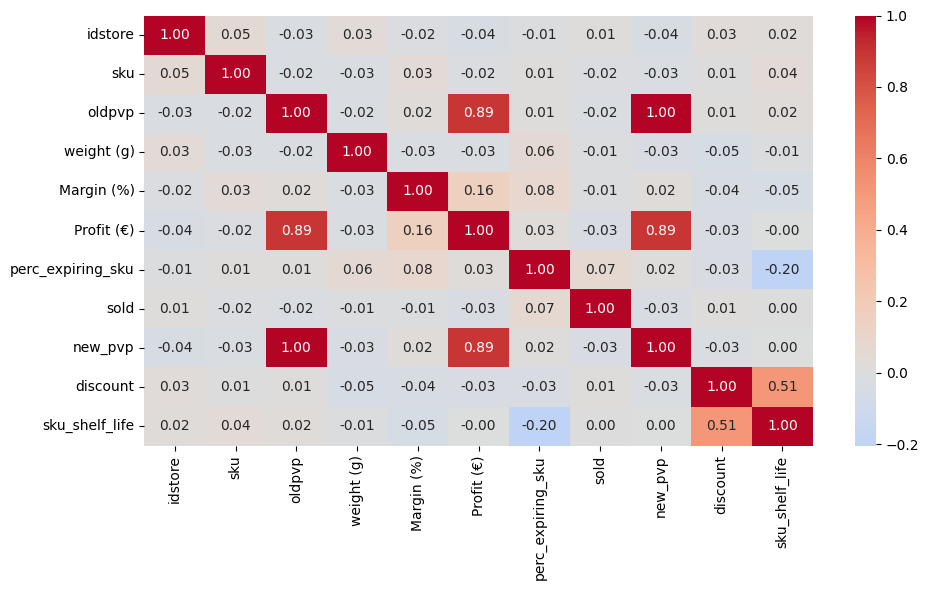

In [399]:
# Matriz de correlação com mapa de cores
corr = df_labels.select_dtypes(include='number').corr()

plt.figure(figsize=(10, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.tight_layout()
plt.show()

### df_store — Limpeza e Imputação

In [400]:
df_store

,idstore,type,selling_square_ft,district
0,1,Large,4762.0,Évora
1,2,Large,12358.0,Bragança
2,3,Large,16159.0,Lisboa
3,4,Large,17903.0,Porto
4,5,Large,16179.0,Coimbra
...,...,...,...,...
337,338,Small,1935.0,Leiria
338,339,Small,2680.0,Portalegre
339,340,Small,866.0,Coimbra
340,341,Small,NaN,Castelo Branco


In [401]:
# Corrigir valor 0 em type: substituir por NaN (valor inválido)
df_store['type'] = df_store['type'].replace(0, pd.NA)
# qual é a loja
df_store[(df_store['type'].isna()) | (df_store['type'] == 0)]

,idstore,type,selling_square_ft,district
193,194,<NA>,NaN,Vila Real


In [402]:
# Tratar o type em falta da loja 194 para o clustering, colocar NA
df_store['type'] = df_store['type'].fillna('NA')

In [403]:
df_store['selling_square_ft'].isna().sum()

np.int64(31)

In [404]:
# criar flag das linhas imputadas sem square ft, 1 para preenchidos 0 para na
df_store['area_missing_flag'] = df_store['selling_square_ft'].isna().astype(int)

In [405]:
# Calcular as diferentes medianas para o fallback
# Mediana por tipo e distrito
median_type_district = df_store.groupby(['type', 'district'])['selling_square_ft'].transform('median')
# Mediana apenas por tipo (caso não haja mais lojas daquele tipo naquele distrito)
median_type = df_store.groupby('type')['selling_square_ft'].transform('median')
# Mediana global (para a loja 194 que não tem 'type' nem área)
global_median = df_store['selling_square_ft'].median()

In [406]:
# aplicar a imputação em cascata
df_store['selling_square_ft'] = (
    df_store['selling_square_ft']
    .combine_first(median_type_district) # primeiro tentar por type e district
    .combine_first(median_type)          # se falhar, tentar por type
    .fillna(global_median)               # se falhar tudo
)

In [407]:
print(df_store[df_store['area_missing_flag'] == 1][['idstore', 'district', 'type', 'selling_square_ft']].head())

     idstore district    type  selling_square_ft
44        45  Setúbal  Medium             6500.0
56        57    Braga  Medium             4600.0
136      137     Beja   Small             1383.5
141      142    Évora   Small             1608.0
147      148   Aveiro   Small              546.0


### Exportação

In [408]:
# Reordenar colunas de forma lógica e guardar
colunas = [
    'idstore', 'sku', 'brand',
    'weight (g)', 'oldpvp', 'new_pvp', 'discount', 
    'Margin (%)', 'Profit (€)','Payment_method',
    'sku_shelf_life','labelling_date', 'expiring_date','perc_expiring_sku', 
    'sell_date','sold' 
]

# Guardar em Excel — versão clean
df_labels[colunas].to_excel('Data_labels_clean.xlsx', index=False)
df_store.to_excel('Data_store_clean.xlsx', index=False)